# CNN chalenge

In this exercise, you will build a CNN to classify images from the Fashion MNIST dataset, train the model, evaluate its performance, and visualize predictions with a confusion matrix.

## Prepare the data

Load the Fashion MNIST dataset using Keras and display the first few images with their labels to get a sense of the data.

In [11]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Task: Normalize the data to have pixel values between 0 and 1
X_train = x_train / 255.0
X_test = x_test / 255.0

# Your code here
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
y_train shape: (60000,)
y_test shape: (10000,)


Visualize 5 random images from the training set with their labels.

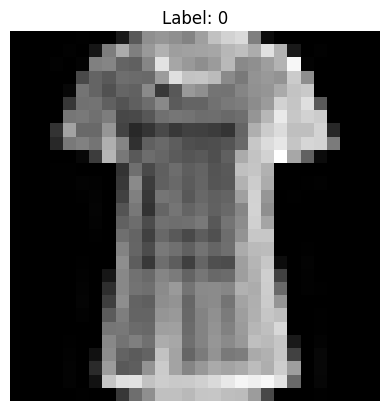

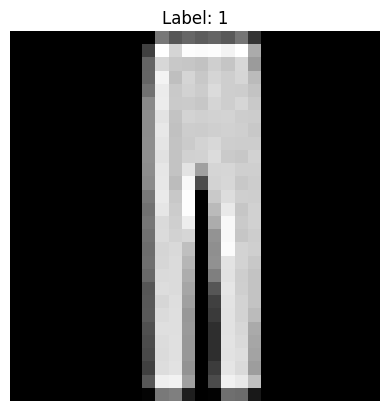

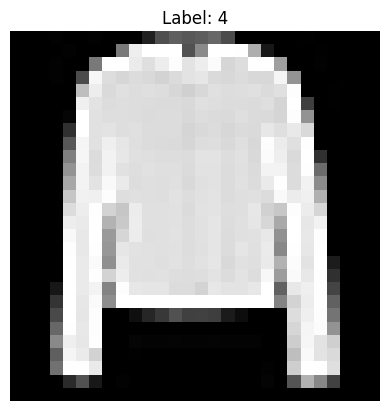

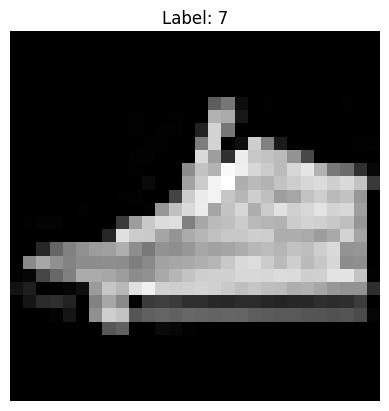

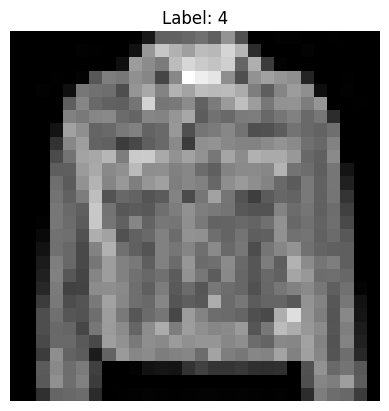

In [12]:
# Your code here for visualization
import random
import matplotlib.pyplot as plt
import numpy as np

random_images = random.sample(list(zip(X_train, y_train)), 5)

for image, label in random_images:
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

Reshape the data to include a channel dimension and confirm the new shape.

In [13]:
# Task: Reshape x_train and x_test to include the channel dimension
# Your code here
X_train = x_train.reshape(-1, 28, 28, 1)
X_test = x_test.reshape(-1, 28, 28, 1)


## Build the CNN model

Create a CNN with at least two convolutional layers, followed by max pooling layers, and a dense output layer.

Rememeber the `Conv2D`, `MaxPooling2D`, `Flatten`, `Dropout` and `Dense`layers.

In [16]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Task: Build your model here
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

Compile your model with an appropriate optimizer, loss function, and metric.

In [17]:
# Task: Compile your model
# Your code here
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Train your model using model.fit(), setting a validation split of 20% and training for at least 10 epochs.

In [18]:
# Task: Train the model and store the training history in a variable
# Your code here
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7928 - loss: 1.2531 - val_accuracy: 0.8633 - val_loss: 0.4050
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8456 - loss: 0.4424 - val_accuracy: 0.8652 - val_loss: 0.3751
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8547 - loss: 0.4098 - val_accuracy: 0.8698 - val_loss: 0.3724
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8565 - loss: 0.3971 - val_accuracy: 0.8730 - val_loss: 0.3722
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8580 - loss: 0.3947 - val_accuracy: 0.8743 - val_loss: 0.3586
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8607 - loss: 0.3875 - val_accuracy: 0.8655 - val_loss: 0.3784
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8586 - loss: 0.3894 - val_accuracy: 0.8683 - val_loss: 0.3686
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8607 -

## Evaluate the model

Evaluate your model on the test set and print the test accuracy.

In [19]:
# Task: Evaluate the model on the test data
# Your code here
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8602 - loss: 0.4148
Test accuracy: 0.8601999878883362


Use your model to predict the labels for the test set. Display 5 test images with their predicted and true labels.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


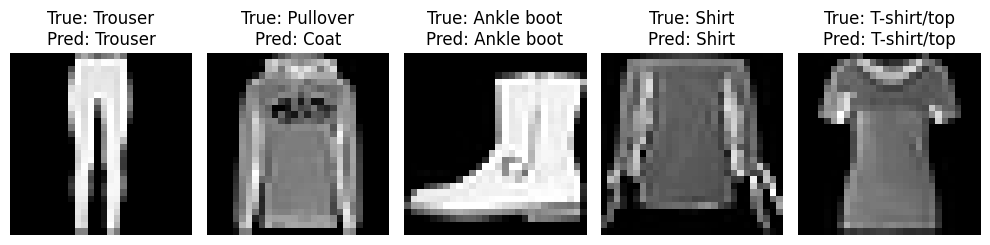

In [23]:
# Task: Use model.predict() and display predictions
# Your code here to display images with predicted and actual labels
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

import random

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(5):
    idx = random.randint(0, len(X_test) - 1)

    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[predicted_labels[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Construct a confusion matrix to visualize how well your model performed across different classes.

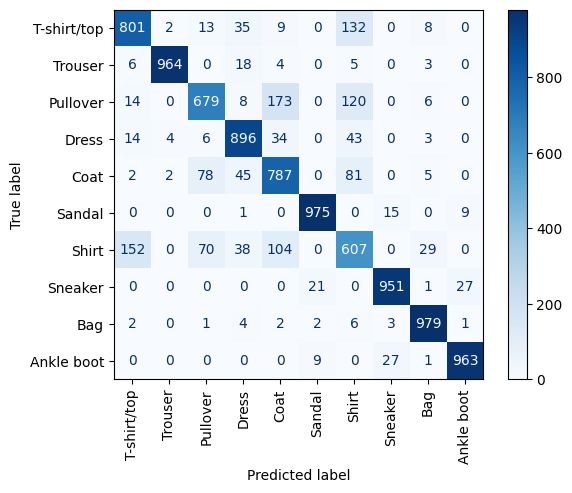

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Task: Create predictions and a confusion matrix
# Your code here
cm = confusion_matrix(y_test, predicted_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()